# Crash-hedged carry, step by step

This notebook rebuilds the whole crash-hedged carry study from the monthly
data panel, in small steps, with the reasoning written out. It ends with the
strategy result: a carry book over 33 currencies that sells the
near-the-money crash insurance on its own positions, buys the deep wing back
as a cap, and earns 1.5 to 1.8%/yr more than plain carry.

You need no options background to follow it. Each step introduces one idea,
shows the numbers, and moves on. The heavier machinery lives in
`src/fxcarry/options.py`, `research/crash_hedged/`, and the two PDFs under
`docs/`. Everything printed here is cross-checked against that pipeline at
the end, twice: once on a single currency-month against
`out/leg_returns.parquet`, and once on the strategy return against
`out/strategy_results.csv`.

**Running it.** The notebook reads the stored outputs under
`research/crash_hedged/out/`, all of which are committed, so it runs top to
bottom in about a minute with nothing else prepared. It prices every leg
itself from the panel rather than reading the answers, which is what makes
the two cross-checks worth anything.

**Where this sits.** The option arithmetic below is the class API:
`Smile.vol` for the quoted smile, and `Black76` for the strike inversion and
the price. The notebooks under `notebooks/tutorial/` teach those pieces one
module at a time, and `notebooks/04_hedged_leg_from_first_principles.ipynb`
rebuilds a single leg of this study from the raw ticker prints with nothing
but numpy and scipy.

Regenerating from raw data rather than from the stored panel works: the
scripts in `research/crash_hedged/` run on the class API, and their own gates
still pass, `validate.py` printing ALL CHECKS PASS and `strategy.py` printing
REGRESSION ANCHORS OK. Run them in the order at the end of this notebook. The
committed outputs are what this notebook reads, so nothing needs regenerating
just to follow along.

In [1]:
import os
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from fxcarry import Black76, Smile

if pathlib.Path.cwd().name == "notebooks":   # run from the repo root
    os.chdir("..")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
PANEL = pd.read_parquet("research/crash_hedged/out/monthly_panel.parquet")
G10 = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]
START, END = "2008-01-01", "2026-06-30"   # post-2008 sample policy
TAU = 1 / 12                              # every option here is one-month
MODEL = Black76()                         # one pricing model, reused throughout
print(f"panel: {len(PANEL):,} rows, {PANEL['ccy'].nunique()} currencies, "
      f"{PANEL['month_end'].min():%Y-%m} to {PANEL['month_end'].max():%Y-%m}")

panel: 12,174 rows, 33 currencies, 1983-12 to 2026-07


## Step 1. The data, one row at a time

One row of the panel is one currency in one month. It carries the exchange
rate, the one-month forward, and that month's option quotes. Everything in
this study comes from these rows.

The raw Bloomberg files behind the panel are long lists of
(ticker, date, field, value). A ticker like `USDJPY25R1M BGN Curncy` reads as:
the pair (USDJPY), the quote type (25R, a 25-delta risk reversal), the tenor
(1M), and the source (BGN, Bloomberg's composite quote). The fields are the
last price, the bid, and the ask. Prices for options are quoted as
volatilities, in percent, which is why a value can be negative.

In [2]:
row = PANEL[(PANEL["ccy"] == "JPY") & (PANEL["month_end"] == "2026-06-30")]
row[["month_end", "ccy", "pair", "spot_native", "fwd_native", "fwd_disc",
     "vol_V_mid", "vol_25R_mid", "vol_25B_mid", "vol_10R_mid", "vol_10B_mid"]]

,month_end,ccy,pair,spot_native,fwd_native,fwd_disc,vol_V_mid,vol_25R_mid,vol_25B_mid,vol_10R_mid,vol_10B_mid
4615,2026-06-30,JPY,USDJPY,162.5500,162.1415,-0.0025,7.8400,-1.1050,0.5500,-2.0250,1.7150


Reading that row: one dollar bought 162.55 yen. The one-month forward was a
bit lower, 162.14. The at-the-money option volatility (`vol_V_mid`) was about
7.8%. The negative risk reversal (`vol_25R_mid`) says the market charged more
for protection against a falling dollar than against a rising one. Keep that
detail in mind, it becomes the whole story later.

## Step 2. What carry is

The textbook trade has three legs. Borrow yen at the Japanese rate, sell the
yen for dollars at spot, put the dollars on deposit at the US rate. A month
later you owe yen that grew slowly and hold dollars that grew faster, and
the gap between the two interest rates is what you keep. That is carry, and
economically that is the whole idea.

Nobody executes it that way. Three legs is three tickets, two deposits and a
balance sheet on both sides. The one-month forward does the same job in one
contract, because both interest rates are already inside the forward price.
FINM 37301 Lecture 1 derives why: a forward is manufactured out of exactly
the borrow and lend package above, so it has to price like it. Writing $S_t$
for the spot price of one unit of foreign currency in dollars, $P_t(T)$ and
$P_t^{*}(T)$ for the domestic and foreign discount factors, and $\tau$ for
the horizon in years,

$$F_t(T) \;=\; S_t\,\frac{P_t^{*}(T)}{P_t(T)} \;=\; S_t\,e^{(r-r^{*})\tau},
\qquad P_t(T)=e^{-r\tau},\quad P_t^{*}(T)=e^{-r^{*}\tau}.$$

Nothing in that derivation is a forecast. It is a cash flow identity, true
whatever anyone thinks the yen will do next month.

The panel stores rates the way the market quotes most of them, in foreign
units per dollar, which is the starred side of the lecture's notation:
$S_t^{*}=1/S_t$ and $F_t^{*}(T)=1/F_t(T)$. Invert the identity and the price
levels cancel, leaving only the two discount factors:

$$\frac{F_t^{*}(T)}{S_t^{*}} \;=\; \frac{S_t}{F_t(T)}
\;=\; \frac{P_t(T)}{P_t^{*}(T)}.$$

Take logs and the `fwd_disc` column falls out, which is one line of
`build_panel.py`:

$$\texttt{fwd\_disc} \;=\; \ln F_t^{*}(T) - \ln S_t^{*}
\;=\; \ln\frac{P_t(T)}{P_t^{*}(T)} \;=\; (r^{*}-r)\,\tau.$$

So the column is the interest rate differential, foreign minus domestic, for
one month, and nothing else. Multiply by 12 and it is the annual rate gap
the three legged version was chasing, read off the forward curve without
touching a single deposit rate. That is also why the repo's patchy rate
files never enter this pipeline.

The name says what the sign means. A currency is at a forward discount when
it is cheaper to buy forward than it is spot, and taking the difference on
the starred side puts the foreign currency in that sentence: `fwd_disc` is
positive exactly when a dollar buys more foreign currency forward than it
buys spot, which is the foreign currency going cheaper forward, which by the
line above means it pays the higher rate. That is the lecture's warning that
the higher yielding currency looks weaker on a forward basis. Take the
difference unstarred instead and you get the identical trade back as the
dollar's forward premium, true but with the dollar as the subject and a
minus sign in front of every carry currency. The starred side is also how
most of the panel already arrives, so one formula covers all 33 names.

The trading rule both papers use is therefore the simplest one there is:
hold the currency long when `fwd_disc` is positive and short when it is
negative, which is "long the high rate currency" with the rates never named.

In [3]:
jun = PANEL[PANEL["month_end"] == "2026-06-30"].set_index("ccy")
r_usd = float(jun["usd_1m"].dropna().iloc[0])   # the lecture's r, domestic
gap = jun["fwd_disc"] * 12                      # (r* - r), annualized
implied = pd.DataFrame({"implied foreign rate r*, %": (r_usd + gap) * 100,
                        "gap over USD, %": gap * 100})
print(f"US 1M bill r = {r_usd * 100:.2f}%")
implied.loc[["CHF", "JPY", "EUR", "AUD", "MXN", "BRL", "TRY"]].round(2)

US 1M bill r = 3.67%


,"implied foreign rate r*, %","gap over USD, %"
ccy,,
CHF,-0.5200,-4.1900
JPY,0.6500,-3.0200
EUR,2.1100,-1.5600
AUD,4.3600,0.7000
MXN,6.8200,3.1600
BRL,12.7200,9.0600
TRY,34.2300,30.5600


No rate data went into that table. The implied column is the forward curve
read backwards through the identity, $r^{*} = r + 12\,\texttt{fwd\_disc}$,
and it lands where a rates screen would put it: the franc slightly negative,
the yen just above zero, the peso near 7% and the lira above 30%. Run the
same arithmetic over every currency and every month and you have the entire
carry signal in this study.

One caution from the lecture rides along with it. A forward is not a
forecast. The lira being 30% a year cheaper forward is a statement about
Turkish and US interest rates, not a prediction that the lira falls 30%.
What the position actually earns is that rate gap plus whatever spot does
over the month, and the second piece is where all the risk sits.

In [4]:
snap = PANEL[PANEL["month_end"] == "2026-06-30"].set_index("ccy")
carry = (snap["fwd_disc"] * 12 * 100).sort_values(ascending=False)
print("annualized carry, June 2026 (% per year):")
print(carry.round(1).to_string())

annualized carry, June 2026 (% per year):
ccy
TRY   30.6000
BRL    9.1000
COP    8.1000
INR    3.7000
IDR    3.2000
ZAR    3.2000
MXN    3.2000
TWD    2.4000
RON    2.1000
HUF    1.7000
PEN    1.5000
AUD    0.7000
PHP    0.6000
NOK    0.5000
PLN    0.1000
GBP    0.0000
CZK   -0.0000
CLP   -0.7000
MYR   -0.8000
KRW   -0.8000
ILS   -1.0000
NZD   -1.3000
HKD   -1.4000
EUR   -1.6000
THB   -1.7000
CAD   -1.7000
DKK   -2.0000
SEK   -2.1000
CNH   -2.5000
SGD   -2.7000
JPY   -3.0000
CHF   -4.2000


TRY pays over 30% a year, BRL and MXN mid to high single digits, while JPY
and CHF cost you 3-4% to hold. A carry book is long the top of this list and
short the bottom. The catch, and the reason this study exists: the currencies
that pay the most are the ones that crash. TRY quoted double-digit carry for
two decades and refunded most of it through depreciation.

correlation -0.65, slope -1.32


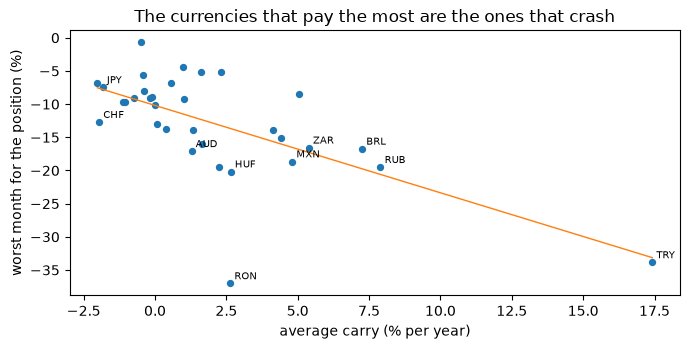

In [5]:
w = PANEL[(PANEL["month_end"] >= START) & (PANEL["month_end"] <= END)].copy()
w["s_usd"] = np.where(w["pair"].str.endswith("USD"),      # dollars per unit
                      w["spot_native"], 1 / w["spot_native"])
w["move"] = w.groupby("ccy")["s_usd"].transform(lambda s: np.log(s).diff())
# sign the move against the position a carry book would hold in that currency
w["against"] = np.sign(w.groupby("ccy")["fwd_disc"].transform("mean")) * w["move"]
crash = w.groupby("ccy").agg(carry=("fwd_disc", "mean"), worst=("against", "min"))
crash["carry"] *= 1200
crash["worst"] *= 100

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.scatter(crash["carry"], crash["worst"], s=18)
for c in ["TRY", "RUB", "BRL", "ZAR", "MXN", "RON", "HUF", "AUD", "JPY", "CHF"]:
    ax.annotate(c, (crash.loc[c, "carry"], crash.loc[c, "worst"]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
slope, intercept = np.polyfit(crash["carry"], crash["worst"], 1)
xs = np.array([crash["carry"].min(), crash["carry"].max()])
ax.plot(xs, intercept + slope * xs, color="C1", lw=1)
ax.set_xlabel("average carry (% per year)")
ax.set_ylabel("worst month for the position (%)")
ax.set_title("The currencies that pay the most are the ones that crash")
plt.tight_layout()
print(f"correlation {crash['carry'].corr(crash['worst']):+.2f}, "
      f"slope {slope:.2f}")

Each dot is one currency since 2008: the average carry it paid, against the
worst single month it handed the position a carry book would hold in it.
Direction matters, so the move is signed. For a currency the book is long, a
bad month is a fall; for one it is short, a bad month is a rally.

The fit slopes down at about 1.3 to 1. A currency paying an extra 1% a year
has come with roughly an extra 1.3% in its worst month, and TRY sits alone
in the corner with 17% a year of carry and a 34% month. That downward slope
is the whole problem this study is about: the payment and the crash are the
same thing seen from two sides, so a carry book cannot keep one and refuse
the other. It can only decide what to pay for insurance against it.

## Step 3. The smile: the market's price list for insurance

Currency options are insurance. A put on the lira pays out when the lira
crashes. The market quotes that insurance in volatility rather than in
dollars, for the same reason bonds are quoted in yield rather than price. A
dollar premium mostly tells you where the strike is, not whether the option
is dear: insurance struck far out always costs less than insurance struck
nearby, because it pays less often. Implied vol is the number you would have
to feed the Black formula to get the quoted premium back, and that formula
already knows where the strike sits and how long the option runs. So a vol
quote is not a forecast. It is the same price in units that say dear or
cheap against a common benchmark, which makes two strikes comparable. Quoted
that way the strikes still disagree with each other, and that disagreement
is the smile. Step 4 shows it on real numbers.

Three numbers per tenor carry the whole list:

* the at-the-money volatility (`V`), the overall price level,
* the risk reversal (`25R`, `10R`), how much more one direction costs than
  the other,
* the butterfly (`25B`, `10B`), how much extra the wings cost over the middle.

Read them the way you would read a yield curve. `V` is the level, the risk
reversal is the slope, the butterfly is the curvature.

Undoing the packaging is one line of arithmetic, and in the library it is
`Smile.vol`: the put-side vol is `atm + bf - rr/2`, the call side is
`atm + bf + rr/2`. A `Smile` holds the three quoted pieces and does nothing
else, and it refuses a delta it was not given rather than interpolating,
because filling in a smile between quotes is a modelling decision. The
"delta" (25, 10) says how far out-of-the-money the insurance is. A 10-delta
put only pays in a serious crash, roughly a 4% move in a month.

One thing the `Smile` built below does *not* do is reorient the wings.
`VolSurface.smile` is the part of the library that flips a risk reversal for
a dollar-based pair so that "call" always means a call on the foreign
currency. This panel was assembled before that step, so the sides here are
the pair's own quoted sides, and Step 6 does the flip explicitly where it
matters. Notebook `tutorial/04_vol.ipynb` works through the orientation on
its own.

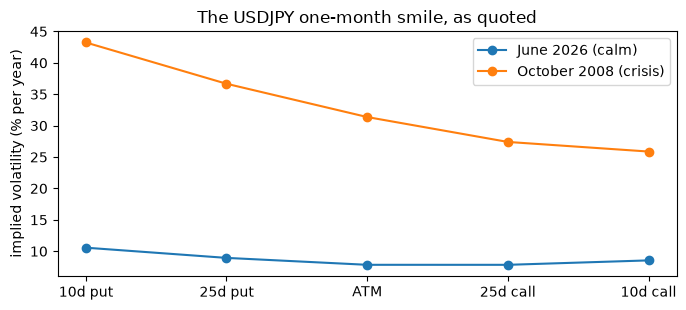

In [6]:
def smile_of(row, field="mid"):
    """The row's quoted smile as a `Smile`, in decimals.

    The panel stores vol points as the terminal quotes them, so the division by 100
    happens here: volatilities cross the library boundary as decimals. Nothing is
    reoriented. `VolSurface.smile` is what flips the wings for a dollar-based pair,
    and this panel was built before that step, so the sides below are still the
    pair's own quoted sides.
    """
    return Smile(
        atm=row[f"vol_V_{field}"] / 100.0,
        risk_reversal={d: row[f"vol_{d}R_{field}"] / 100.0 for d in (10, 25)},
        butterfly={d: row[f"vol_{d}B_{field}"] / 100.0 for d in (10, 25)},
    )


def smile_points(ccy, date, field="mid"):
    r = PANEL[(PANEL["ccy"] == ccy) & (PANEL["month_end"] == date)].iloc[0]
    smile = smile_of(r, field)
    pts = {f"{d}d put": smile.vol(d, "put") * 100 for d in (10, 25)}
    pts["ATM"] = smile.vol() * 100
    pts |= {f"{d}d call": smile.vol(d, "call") * 100 for d in (25, 10)}
    return pd.Series(pts)

calm = smile_points("JPY", "2026-06-30")
crisis = smile_points("JPY", "2008-10-31")
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(calm.index, calm.values, marker="o", label="June 2026 (calm)")
ax.plot(crisis.index, crisis.values, marker="o", label="October 2008 (crisis)")
ax.set_ylabel("implied volatility (% per year)")
ax.set_title("The USDJPY one-month smile, as quoted")
ax.legend()
plt.tight_layout()

Two things to see in the picture. The smile is not flat: out-of-the-money
insurance costs more (in vol terms) than at-the-money, and one side costs
more than the other. And the whole curve moves: in October 2008 the same
insurance cost four to five times its calm-market price. The smile is a
price list, and prices change with fear.

## Step 4. From a quote to a dollar price

Two calls on the pricing model turn a vol quote into a tradable option.
First, `Black76.strike_from_delta` finds the strike a "25-delta" quote refers
to. Second, `Black76.value` prices the option at that strike, which is the
standard Black formula written on the forward rather than on spot. Writing it
on the forward is what keeps interest rates out of it: an option on one
currency against another has two rates in it, and the outright forward
already prices their difference, so only a single discount factor survives.
`Black76.atm_strike` gives the strike the market calls at-the-money, which is
not the forward but `F exp(sigma^2 tau / 2)`, the strike at which a straddle
has zero net delta.

A delta is a coordinate rather than a moneyness, so turning one into a strike
takes the model, and the strike moves when the volatility fed in moves. The
library implements the plain spot delta and says so: FX quotes four delta
conventions, and the premium-adjusted ones have no closed-form inverse and
are not implemented. Notebook `tutorial/05_options.ipynb` derives the
inversion and checks it round-trips.

The useful way to hold on to what a delta means here is that it is roughly
the chance the option ends up paying. A 25-delta put pays in about one month
out of four, a 10-delta put in about one out of ten. So the table below is a
menu of deductibles: further out is cheaper cover and a bigger loss you keep
for yourself. Later steps call these three choices the rungs of the ladder,
which means nothing more than how far out of the money the protection is
bought: at-the-money, 25-delta, or 10-delta.

Worked example, insuring a short-yen position for one month in June 2026:

In [7]:
r = PANEL[(PANEL["ccy"] == "JPY") & (PANEL["month_end"] == "2026-06-30")].iloc[0]
S, F, r_usd = r["spot_native"], r["fwd_native"], r["usd_1m"]
r_jpy = r_usd - np.log(S / F) * 12          # implied by the forward (CIP)
smile = smile_of(r)

ladder = {}
for name, delta in [("ATM", None), ("25-delta", 25), ("10-delta", 10)]:
    sig = smile.vol(delta, "put")           # delta=None returns at the money
    K = (MODEL.atm_strike(F, sig, TAU) if delta is None
         else MODEL.strike_from_delta(delta / 100, "put", F, sig, TAU,
                                      base_rate=r_usd))
    prem = MODEL.value("put", F, K, sig, TAU, discount=np.exp(-r_jpy * TAU))
    ladder[name] = {"strike": K, "% below spot": (K / S - 1) * 100,
                    "implied vol, %": sig * 100,
                    "cost, % of spot per month": prem / S * 100}
pd.DataFrame(ladder).T.round(3)

,strike,% below spot,"implied vol, %","cost, % of spot per month"
ATM,162.1830,-0.2260,7.8400,0.9130
25-delta,159.4060,-1.9340,8.9420,0.3900
10-delta,156.0060,-4.0260,10.5670,0.1460


Two columns, two different messages.

The premiums fall as you move out, and that tells you nothing at all. Of
course the far strike costs less, it pays out less often. That ordering would
hold under any model, on any day, in any currency.

The vols go the other way. They rise, 7.84 to 8.94 to 10.57. That is
information, and you cannot see it in the premium column. Implied vol is the
number you would have to feed the Black formula to get the quoted premium
back, and that formula already accounts for **moneyness and time**, so anything left in the vol is something it could not
explain from these two. When the 10-delta quotes at 10.57% and the
at-the-money at 7.84%, the market is charging more per unit of risk for the
far strike than a single vol lognormal world would. That gap is not
mechanical. It is the market's opinion about the tail, and it is exactly what
this study goes on to measure and sell.

Now read the cost column against what the position earns. The short-yen leg
pays about 3% a year, which is 0.25% a month. Full at-the-money insurance
costs 0.9% a month, more than triple the income. The 10-delta disaster
insurance costs 0.15% a month. Where you buy on this ladder decides whether
the trade survives, and that observation drove the entire research program.

## Step 5. What twenty years of measurement said

The pipeline in `research/crash_hedged/` repeats the Step 4 arithmetic for
every currency and every month since 2006. It builds the carry book three
times over, once buying at-the-money protection, once 25-delta, once
10-delta, and compares each against the unhedged book. Five validation gates
guard it, including one identity that must hold to machine precision in all
1,716 months where insurance paid out.

The measured quantity is how much carry the hedged book surrenders to the
unhedged one. Jurek's paper calls that the give-up, and `analysis.py` stores
it under that name in the `giveup10_ann` and `giveup25_ann` columns, so the
notebook keeps the word. It is desk shorthand rather than a textbook term.
Averaged over the sample it comes to

$$\text{give-up} \;=\;
\underbrace{\text{premiums paid}}_{\text{small, every month}} \;-\;
\underbrace{\text{payouts received}}_{\text{large, rarely}}$$

Positive means twenty years of policies did not pay for themselves, and that
excess is what the literature calls the crash premium. The finding fits on
one line:

$$\delta \downarrow \quad\Longrightarrow\quad \sigma_{\text{implied}} \uparrow
\quad\text{but}\quad \text{give-up} \downarrow$$

Buy further out of the money and the market quotes you a higher volatility,
which is the Step 3 smile, and yet the cover comes out closer to fair,
because the crashes it pays on are big enough to earn the premium back.

In [8]:
per_ccy = pd.read_csv("research/crash_hedged/out/per_currency.csv", index_col=0)
show = (per_ccy[["pct_long", "carry_long", "z_ann", "giveup_10d_ann", "giveup_25d_ann"]]
        if "giveup_10d_ann" in per_ccy.columns else per_ccy)
cols = {"pct_long": "% months long", "carry_long": "carry when long",
        "z_ann": "what the leg earned", "giveup10_ann": "cost of 10d insurance",
        "giveup25_ann": "cost of 25d insurance"}
tbl = per_ccy.rename(columns=cols)
keep = [c for c in cols.values() if c in tbl.columns]
(tbl[keep].head(10) * 100).round(1)

,% months long,carry when long,what the leg earned,cost of 10d insurance,cost of 25d insurance
ccy,,,,,
TRY,100.0000,16.8000,0.9000,-0.3000,1.0000
RUB,95.1000,7.7000,1.0000,0.3000,0.3000
BRL,100.0000,7.2000,4.5000,0.6000,1.9000
ZAR,100.0000,5.2000,1.7000,1.1000,2.2000
INR,98.4000,5.0000,0.8000,0.5000,0.8000
MXN,100.0000,4.6000,2.8000,0.5000,1.5000
COP,94.3000,4.3000,2.9000,1.0000,1.6000
IDR,100.0000,4.3000,1.2000,1.0000,2.3000
HUF,81.6000,3.6000,3.2000,0.8000,1.0000


G10: %/yr  10d +0.13  25d +0.18  (25d dearer 4/9)   |  % of premium  10d +7  25d +3  (10d dearer 5/9)
EM : %/yr  10d +0.54  25d +0.91  (25d dearer 18/24)   |  % of premium  10d +35  25d +21  (10d dearer 20/24)


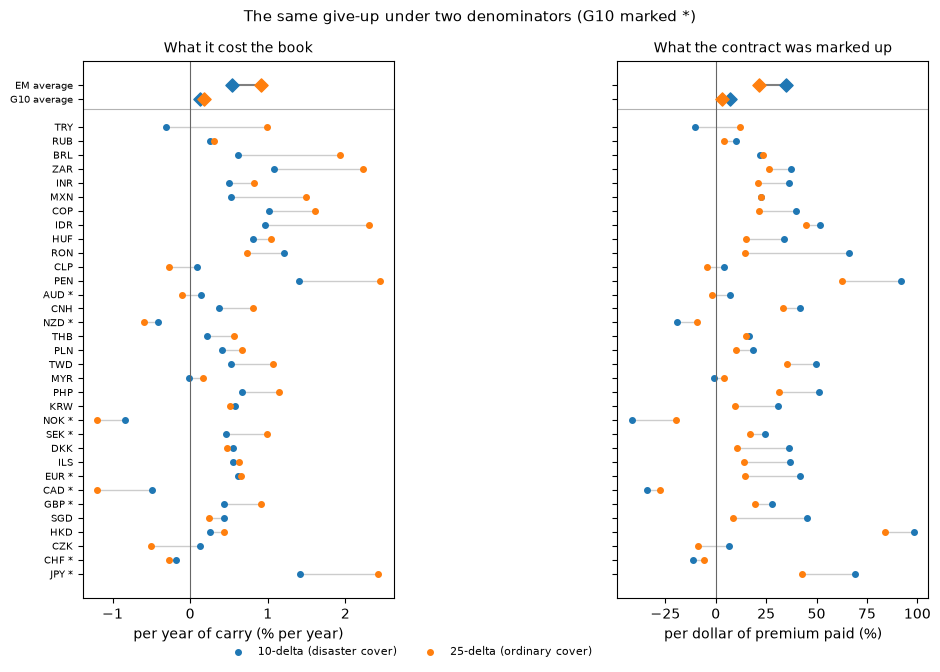

In [9]:
per_ccy["share10"] = per_ccy["giveup10_ann"] / per_ccy["prem10_ann"] * 100
per_ccy["share25"] = per_ccy["giveup25_ann"] / per_ccy["prem25_ann"] * 100
d = per_ccy.iloc[::-1]                     # file runs high carry first
y = np.arange(len(d))
is_g10 = per_ccy.index.isin(G10)
groups = [("G10 average", per_ccy[is_g10]), ("EM average", per_ccy[~is_g10])]
ys = [len(d) + 1.0, len(d) + 2.0]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 6.8), sharey=True)
panels = [(axes[0], "giveup10_ann", "giveup25_ann", 100,
           "per year of carry (% per year)", "What it cost the book"),
          (axes[1], "share10", "share25", 1,
           "per dollar of premium paid (%)", "What the contract was marked up")]
for ax, c10, c25, k, xlab, title in panels:
    ax.hlines(y, d[c10] * k, d[c25] * k, color="0.8", lw=1)
    ax.scatter(d[c10] * k, y, s=16, zorder=2, label="10-delta (disaster cover)")
    ax.scatter(d[c25] * k, y, s=16, zorder=2, label="25-delta (ordinary cover)")
    for (lab, sub), yy in zip(groups, ys):     # group means, same units
        a, b = sub[c10].mean() * k, sub[c25].mean() * k
        ax.hlines(yy, a, b, color="0.5", lw=1.5)
        ax.scatter([a], [yy], s=45, color="C0", marker="D", zorder=3)
        ax.scatter([b], [yy], s=45, color="C1", marker="D", zorder=3)
    ax.axhline(len(d) + 0.3, color="0.7", lw=0.8)
    ax.axvline(0, color="0.4", lw=0.8)
    ax.set_xlabel(xlab)
    ax.set_title(title, fontsize=10)
axes[0].set_yticks(list(y) + ys)
axes[0].set_yticklabels([f"{c} *" if c in G10 else c for c in d.index]
                        + [lab for lab, _ in groups], fontsize=7)
axes[0].legend(fontsize=8, loc="upper center", bbox_to_anchor=(1.05, -0.07),
               ncol=2, frameon=False)
fig.suptitle("The same give-up under two denominators (G10 marked *)", fontsize=11)
plt.tight_layout()

for name, m in [("G10", is_g10), ("EM ", ~is_g10)]:
    s = per_ccy[m]
    print(f"{name}: %/yr  10d {s['giveup10_ann'].mean() * 100:+.2f}  "
          f"25d {s['giveup25_ann'].mean() * 100:+.2f}  "
          f"(25d dearer {int((s['giveup25_ann'] > s['giveup10_ann']).sum())}/{int(m.sum())})"
          f"   |  % of premium  10d {s['share10'].mean():+.0f}  "
          f"25d {s['share25'].mean():+.0f}  "
          f"(10d dearer {int((s['share10'] > s['share25']).sum())}/{int(m.sum())})")

Two denominators, two different answers, and both are true.

Left, per year of carry, which is the unit the book actually feels. EM gives
up 0.9% a year at 25-delta against 0.5% at 10-delta, and the 25-delta is the
dearer of the two for 18 of its 24 names. That gap, 0.37% a year on average,
is what Step 6 sells. G10 has no such gap: its two diamonds sit on top of
each other, 0.13% against 0.18%, for an average gap of 0.05% a year.

Right, per dollar of premium paid, which is the unit that says whether a
contract was dear. The order flips. EM buyers lost about 35% of what they
spent on 10-delta cover against about 21% on 25-delta, and the 10-delta is
the more marked up of the two for 25 of the 33 names. Per dollar, the deep
wing is the priciest thing in this study, not the fair rung.

The panels do not contradict each other. The 25-delta premium averages about
2.9 times the 10-delta one, so a smaller markup on a much larger contract
still surrenders more carry per year. The spread nets positive because of
that size difference, not because either leg is fairly priced.

On G10, the pair supports only what the diamonds show: no tilt is measurable
on average, under either denominator. That is not a claim about any single
name. JPY bought the dearest 10-delta cover in the sample, 1.4% a year and
69% of its premium, while NOK and CAD sit furthest left on both panels. G10
dispersion runs several times its mean.

## Step 6. The strategy: sell the near rung, buy the far one back

Against each currency the carry book holds, do two option trades: sell the
25-delta protection and buy the 10-delta protection. Together these form a
short put spread on the position's crash side.

The mental model is an insurance company. Selling the 25-delta protection
makes you the insurer for ordinary crashes. Buying the 10-delta protection
is your reinsurance: past that point the loss belongs to somebody else. You
keep the premiums for everything in between, and a real disaster stops being
your problem.

Step 5 said which leg carries the money, and it is not the one with the
bigger markup. Going from the 25-delta out to the 10-delta, the markup rate
rises from 18% of premium to 29%, but the contract shrinks by more, from
5.19%/yr of premium to 1.82%/yr. Rate up 1.6 times, size down 2.9 times, so
the dollars fall by 1.7 times. The wing is the boutique with the fat margin
and no turnover; the 25-delta is the supermarket. The supermarket earns
more.

That settles the structure, including the trade not to do. Selling the wing,
which is the highest-margin contract in the study, is dominated:

| book, net of forward costs, 2008 to 2026 | return | Sharpe | worst month | skew |
| --- | --- | --- | --- | --- |
| plain carry | 5.05%/yr | 0.58 | -10.3% | -0.70 |
| sell 10-delta only | 6.40%/yr | 0.62 | -14.7% | -1.43 |
| sell 25-delta only | 7.87%/yr | 0.65 | -16.6% | -1.58 |
| sell 25-delta, buy 10-delta | 6.53%/yr | 0.63 | -12.2% | -1.01 |

Selling the wing earns less than the spread and runs a tail 2.5 points
deeper. Its markup is high because the risk is nasty, and the dollars paid
for carrying it are small. So the wing is worth owning, not selling. Against
the other direction, the spread hands back 1.34%/yr to the naked 25-delta
sale and gets 4.4 points of worst month for it. That exchange is the
strategy, and it is a risk decision rather than a relative value one.

Three properties still make it a strategy rather than a bet. The income is
the difference between the two measured give-ups, collected up front every
month. The extra risk is capped: past the 10-delta strike the bought option
kicks in, so the worst the overlay can lose is the distance between the two
strikes, about 2% per position per month. And there are no parameters to
tune. The strikes are the two the market quotes.

The code below prices one leg the way the pipeline does. It is the same
logic as `research/crash_hedged/hedged_carry.py`, written for reading.

In [10]:
def one_leg(r):
    """One currency, one month: plain carry, the naked sale, the spread."""
    base_is_fcu = r["pair"].endswith("USD")     # e.g. AUDUSD vs USDJPY
    S = r["spot_native"] if base_is_fcu else 1 / r["spot_native"]
    F = r["fwd_native"] if base_is_fcu else 1 / r["fwd_native"]
    S_next = r["spot_next"]                     # dollars per foreign unit
    hold = 1.0 if r["fwd_disc"] > 0 else -1.0   # long the payers, short the rest
    grow = np.exp(r["usd_1m"] * TAU)

    carry_leg = hold * grow * (S_next / F - 1.0)

    # protection insures the direction that hurts this position
    side = "put" if hold > 0 else "call"        # on the foreign currency
    quoted = side if base_is_fcu else ("call" if side == "put" else "put")
    smile = smile_of(r)                        # still in the pair's own direction
    strikes, premiums = {}, {}
    for d in (25, 10):
        sig = smile.vol(d, quoted)
        # work out the strike in the pair's own quoting direction, then flip
        if base_is_fcu:
            K = MODEL.strike_from_delta(
                d / 100, side, F, sig, TAU,
                base_rate=r["usd_1m"] - np.log(F / S) / TAU)
        else:
            K = 1 / MODEL.strike_from_delta(
                d / 100, quoted, r["fwd_native"], sig, TAU,
                base_rate=r["usd_1m"])
        strikes[d] = K
        premiums[d] = MODEL.value(side, F, K, sig, TAU,
                                  discount=np.exp(-r["usd_1m"] * TAU))

    def payout(K):
        return max(hold * (K - S_next), 0.0)    # what the protection pays

    naked = (premiums[25] * grow - payout(strikes[25])) / F        # sold the 25d
    wing = (payout(strikes[10]) - premiums[10] * grow) / F         # bought the 10d
    return carry_leg, carry_leg + naked, carry_leg + naked + wing

rows = PANEL.sort_values(["ccy", "month_end"]).copy()
rows["spot_next"] = rows.groupby("ccy").apply(
    lambda g: (g["spot_native"].where(g["pair"].str.endswith("USD"),
                                      1 / g["spot_native"])).shift(-1),
    include_groups=False).reset_index(level=0, drop=True)
need = ["spot_next", "usd_1m", "vol_V_mid", "vol_25R_mid", "vol_25B_mid",
        "vol_10R_mid", "vol_10B_mid"]
rows = rows.dropna(subset=need)
out = rows.apply(one_leg, axis=1, result_type="expand")
rows[["carry_leg", "naked_leg", "strategy_leg"]] = out.values
rows["ret_month"] = rows["month_end"] + pd.offsets.MonthEnd(1)
print(f"{len(rows):,} currency-months priced")

8,232 currency-months priced


One check before trusting any of it: the row this notebook computes must
match the row the validated pipeline computed. Same currency, same month,
same numbers to four decimals.

In [11]:
mine = rows[(rows["ccy"] == "JPY") & (rows["month_end"] == "2026-06-30")].iloc[0]
stored = pd.read_parquet("research/crash_hedged/out/leg_returns.parquet")
theirs = stored[(stored["ccy"] == "JPY")
                & (stored["month_end"] == "2026-06-30")].iloc[0]
print(f"this notebook : carry {mine['carry_leg']:+.6f}, "
      f"strategy {mine['strategy_leg']:+.6f}")
print(f"pipeline      : carry {theirs['z_unhedged']:+.6f}, "
      f"strategy {theirs['z_ps']:+.6f}")
assert abs(mine["carry_leg"] - theirs["z_unhedged"]) < 1e-10
assert abs(mine["strategy_leg"] - theirs["z_ps"]) < 1e-10
print("match.")

this notebook : carry +0.000362, strategy +0.002820
pipeline      : carry +0.000362, strategy +0.002820
match.


## Step 7. From legs to a book

The book is the team's standard construction: each month, rank all
currencies by carry, put one dollar long across the five highest and one
dollar short across the five lowest, a fifth of a dollar per name. Returns
below are per dollar of one side, the same convention the team reports. A
currency enters only when the ranking and the sign rule agree, which drops
a handful of borderline months.

Ranking rather than levels is the point. You never have to decide what the
right yield for the lira is, only that it pays more this month than the yen
does, and the book earns the spread between the two ends of the list.

The ranked universe is every currency with option quotes, 33 names after
the July 22 pulls. The ruble is in until its market froze in February 2022
and out after, because a price nobody can trade at is not a price.

In [12]:
rows["rank"] = rows.groupby("month_end")["fwd_disc"].rank(ascending=False)
rows["n"] = rows.groupby("month_end")["ccy"].transform("count")
K_LEG = 5
held = rows[((rows["rank"] <= K_LEG) & (rows["fwd_disc"] > 0))
            | ((rows["rank"] > rows["n"] - K_LEG) & (rows["fwd_disc"] < 0))]
ARMS = ["carry_leg", "naked_leg", "strategy_leg"]
book = held.groupby("ret_month")[ARMS].sum(min_count=1) / K_LEG
book = book[(book.index >= START) & (book.index <= END)]
print(f"{len(book)} months, {START[:4]} to {END[:4]}")

222 months, 2008 to 2026


## Step 8. Costs

Two costs matter and they enter differently.

Forwards cost money to roll every month. We charge the position the quoted
points spread for the monthly roll, and the full outright spread whenever a
weight changes, all from our own bid and ask data. This drag hits the plain
book and the strategy book identically, because they hold the same forwards.

Options cost money to trade too, and this cost only touches the overlay.
The numbers below use mid quotes; the honest range around them is in Step 9.

In [13]:
# The forward cost comes from the validated pipeline rather than being re-derived here.
# out/tutorial_series.parquet is that pipeline's own output, written by strategy.py, so
# this reads the audited number instead of importing the module across directories.
series = pd.read_parquet("research/crash_hedged/out/tutorial_series.parquet")
fwd_cost = series["fwd_cost"].reindex(book.index).fillna(0.0)
net = book.sub(fwd_cost, axis=0)
print(f"forward cost drag: {fwd_cost.mean() * 1200:.2f}% per year")

forward cost drag: 0.89% per year


## Step 9. The result

Annualized return and Sharpe ratio, net of forward costs, for the plain
carry book and the strategy, plus the difference between them with a
Newey-West t-statistic. The difference is the overlay's own profit stream,
and forward costs cancel out of it entirely. It is not the same thing as
alpha, and Step 10 takes that apart.

In [14]:
def summarize(r):
    r = r.dropna()
    ann = r.mean() * 12
    return ann, ann / (r.std() * np.sqrt(12))

def nw_t(s):
    s = s.dropna()
    return float(sm.OLS(s.values, np.ones(len(s))).fit(
        cov_type="HAC", cov_kwds={"maxlags": 6}).tvalues[0])

NAMES = [("carry_leg", "plain carry"), ("naked_leg", "sell 25d only"),
         ("strategy_leg", "strategy")]
table = []
for start in ["2008-01-01", "2009-01-01"]:
    w = net[net.index >= start]
    diff = (w["strategy_leg"] - w["carry_leg"]).dropna()
    for col, name in NAMES:
        ann, sr = summarize(w[col])
        table.append({"from": start[:4], "book": name,
                      "return %/yr": ann * 100, "Sharpe": sr})
    table.append({"from": start[:4], "book": "overlay alone",
                  "return %/yr": diff.mean() * 1200,
                  "Sharpe": summarize(diff)[1], "t-stat": nw_t(diff)})
results = pd.DataFrame(table).set_index(["from", "book"]).round(2)
results

return %/yr  Sharpe  t-stat
from book                                      
2008 plain carry         5.0500  0.5800     NaN
     sell 25d only       7.8700  0.6500     NaN
     strategy            6.5300  0.6300     NaN
     overlay alone       1.4700  0.6500  2.9600
2009 plain carry         6.1300  0.7600     NaN
     sell 25d only       9.4600  0.8500     NaN
     strategy            7.9200  0.8300     NaN
     overlay alone       1.7900  0.8800  3.7600

matches out/strategy_results.csv.


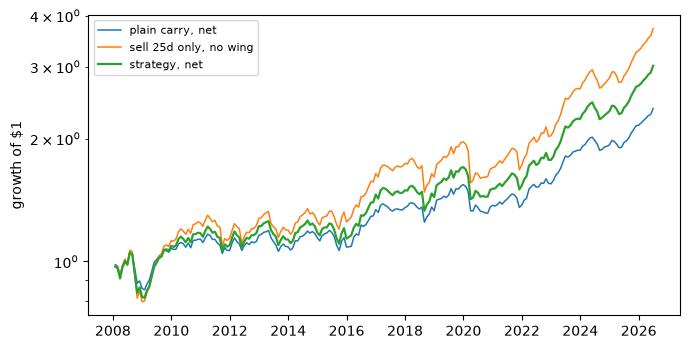

In [15]:
# cross-check against the pipeline's own strategy table (the broad book)
anchors = pd.read_csv("research/crash_hedged/out/strategy_results.csv")
a = anchors[(anchors["window"] == 2008) & (anchors["book"] == "sorted-broad")]
mine = results.loc[("2008", "strategy"), "return %/yr"] / 100
theirs = float(a[a["arm"] == "strategy"]["net_ann"].iloc[0])
assert abs(mine - theirs) < 5e-4, (mine, theirs)
print("matches out/strategy_results.csv.")

wealth = (1 + net.dropna()).cumprod()
fig, ax = plt.subplots(figsize=(7, 3.6))
for col, lab in [("carry_leg", "plain carry, net"),
                 ("naked_leg", "sell 25d only, no wing"),
                 ("strategy_leg", "strategy, net")]:
    ax.plot(wealth.index, wealth[col], label=lab,
            lw=1.6 if col == "strategy_leg" else 1.1)
ax.set_yscale("log")
ax.set_ylabel("growth of $1")
ax.legend(fontsize=8)
plt.tight_layout()

## Step 9b. Why not just sell the 25-delta and skip the wing?

The naked line finishes highest, so the question has to be answered rather
than avoided. It is not answered by the Sharpe ratio, which is where most
overlay pitches stop.

In [16]:
def risk(s):
    s = s.dropna()
    nav = (1 + s).cumprod()
    dd = (nav / nav.cummax() - 1).min()
    return {"return %/yr": s.mean() * 1200,
            "vol %": s.std() * np.sqrt(12) * 100,
            "Sharpe": s.mean() * 12 / (s.std() * np.sqrt(12)),
            "Sortino": s.mean() * 12 / (s[s < 0].std() * np.sqrt(12)),
            "skew": s.skew(), "exc kurt": s.kurtosis(),
            "worst mo %": s.min() * 100,
            "CVaR 5% ": s[s <= s.quantile(0.05)].mean() * 100,
            "max DD %": dd * 100}

w = net[net.index >= START].dropna()
risks = pd.DataFrame({name: risk(w[col]) for col, name in NAMES}).T
risks["ret / |CVaR|"] = risks["return %/yr"] / risks["CVaR 5% "].abs()
# lever each book to plain carry's worst month, then compare what it earns
scale = w["carry_leg"].min() / w.min()
risks["at equal tail"] = (risks["return %/yr"] * scale.values)
risks.round(2)

,return %/yr,vol %,Sharpe,Sortino,skew,exc kurt,worst mo %,CVaR 5%,max DD %,ret / |CVaR|,at equal tail
plain carry,5.0500,8.7200,0.5800,0.7600,-0.7000,2.1000,-10.3400,-5.8500,-18.7300,0.8600,5.0500
sell 25d only,7.8700,12.0800,0.6500,0.6800,-1.5800,4.8600,-16.5900,-9.2800,-25.2500,0.8500,4.9100
strategy,6.5300,10.4200,0.6300,0.7600,-1.0100,2.5400,-12.2000,-7.3400,-22.5300,0.8900,5.5300


Read the table across and the naked sale loses on every measure that
respects the shape of the risk.

Sharpe does not decide it. 0.65 against 0.63 is noise, and if Sharpe were
the criterion you would take the naked sale and stop reading. But Sharpe
divides by a standard deviation, which counts a 3% gain and a 3% loss as
the same size of event. Selling puts breaks that assumption deliberately.

Sortino, which divides by downside deviation only, flips the ranking: 0.68
for the naked sale against 0.76 for the strategy, which is exactly where
plain carry already sits. The skew and kurtosis columns say why. Giving the
wing away doubles the negative skew, -0.70 to -1.58, and more than doubles
the excess kurtosis. The extra return arrives in small monthly pieces and
the extra risk arrives all at once.

The decisive test is to compare the books at the same risk instead of the
same notional. Lever each one until its worst month matches plain carry's
-10.3%, which is the last column. The naked sale then pays 4.91% a year.
Plain carry, doing nothing at all, pays 5.05%. The strategy pays 5.53%. So
the naked sale's headline 7.87% is not a better trade, it is the same trade
with more tail bolted on, and once the tail is levered back out it earns
less than not trading. Return per unit of CVaR says it more compactly: 0.85
naked, 0.86 plain, 0.89 strategy.

One argument sits outside the table and is the strongest of them. Every
number in the worst-month, CVaR and drawdown columns measures what did
happen. A naked short put has no floor, so its real worst case is not
-16.6%, it is whatever the next crash delivers. The spread's worst case is
(K25 - K10)/F per leg-month, a property of the contract rather than an
estimate from the sample, so it holds in months this data has never seen.
That is what the wing is bought for, and it is why 1.34% a year is a
reasonable price to pay for it.

## Step 10. What to trust and what to check

The strategy beats plain carry by about 1.5% a year with a t-statistic near
3, the 2008 crash is inside the sample, and the book itself runs at a net
Sharpe near 0.6, in line with the team's headline book.

Most of that pickup is not alpha. Regress the overlay on the plain carry
book and it comes back with a beta of 0.18 (t 9.3) and an R-squared of 0.49,
leaving an intercept of +0.56%/yr with t 1.64 from 2008, or +0.78%/yr with
t 2.23 from 2009. So roughly two-thirds of the 1.5% is additional carry
exposure that the overlay picks up by being short puts on a long carry book.
The smile-specific residual is positive on both windows but only marginally
measurable. Read the headline as a better carry book, not as a separate
source of return.

Two more honest conditions. First, the option numbers use mid quotes. At the
full quoted spread the edge inverts, and the break-even is executing inside
roughly 40 to 50% of the spread. Whether real EM option fills beat that is a
question for the desk, not for a backtest. Second, the ruble contributes
history only up to its February 2022 freeze.

One correction this study makes to its own earlier claim: the team's data
pull had reported six currencies (IDR among them) as having no option
quotes, and an earlier draft treated them as uninsurable. A fresh pull on
this terminal found full smiles for all six. The gap was in the pull, not
the market, and IDR turned out to have one of the widest gaps between its
25-delta and 10-delta give-up, which is the gap the strategy sells.

Ideas that were tried and did not improve things, weighting by the quoted
premium gap and leveraging the hedged book on its floor, are in
`research/crash_hedged/LOG.md` with the numbers.

To replicate everything from raw data, run, in order:
`build_panel.py`, `hedged_carry.py`, `validate.py` (it must print
ALL CHECKS PASS), `analysis.py`, `strategy.py` (it must print
REGRESSION ANCHORS OK), then this notebook.